# Data Quality Assessment and Remediation for the NovaCred Credit Application Dataset

This notebook performs a comprehensive **data quality assessment and data cleaning** on the NovaCred credit applications dataset.

## Data quality dimensions assessed
- **Completeness**: missing values in critical fields
- **Uniqueness**: duplicate primary keys and duplicate records
- **Consistency**: standardised category values (for example gender), consistent types
- **Validity**: values respect logical rules and ranges
- **Accuracy**: format checks for fields like email, SSN, IP address, ZIP code

## Data cleaning actions
- Removal of corrupt records
- Deduplication based on the primary key (`_id`)
- Standardisation of categorical values (for example gender labels)
- Trimming and formatting of string fields
- Handling of null and empty values
- Creation of cleaned and validated columns

## Deliverables
- Quantified issue metrics (counts and percentages)
- Examples of affected records (IDs)
- Remediated dataset with clean columns and validation flags

# 🟤 Bronze Layer – Raw Data Ingestion

In this step, the raw credit application dataset is ingested from the JSON source into Spark.

The following preview shows the dataset immediately after ingestion, before any filtering or cleaning steps are applied.

In [0]:
from pyspark.sql import functions as F

input_path = "/Volumes/workspace/default/raw_data/raw_credit_applications.json"

df_raw = (
    spark.read
        .option("multiline", "true")
        .option("mode", "PERMISSIVE")
        .json(input_path)
)

print("Total raw rows ingested:", df_raw.count())

display(df_raw.limit(5))

Total raw rows ingested: 502


_id,applicant_info,decision,financials,loan_purpose,notes,processing_timestamp,spending_behavior
app_200,"List(2001-03-09, jerry.smith17@hotmail.com, Jerry Smith, Male, 192.168.48.155, 596-64-4340, 10036)","List(null, null, false, algorithm_risk_score)","List(73000, null, 23, 0.2, 31212)",null,null,2024-01-15T00:00:00Z,"List(List(480, Shopping), List(790, Rent), List(247, Alcohol))"
app_037,"List(1992-03-31, brandon.walker2@yahoo.com, Brandon Walker, M, 10.1.102.112, 425-69-4784, 10032)","List(null, null, false, algorithm_risk_score)","List(78000, null, 51, 0.18, 17915)",null,null,null,"List(List(608, Rent), List(96, Dining), List(243, Healthcare))"
app_215,"List(1989-10-24, scott.moore94@mail.com, Scott Moore, Male, 10.240.193.250, 370-78-5178, 10075)","List(59000, 3.7, true, null)","List(61000, null, 41, 0.21, 37909)",vacation,null,null,"List(List(109, Rent))"
app_024,"List(1983-04-25, thomas.lee6@protonmail.com, Thomas Lee, Male, 192.168.175.67, 194-35-1833, 10077)","List(34000, 4.3, true, null)","List(103000, null, 70, 0.35, 0)",null,null,null,"List(List(575, Fitness))"
app_184,"List(1999-05-21, brian.rodriguez86@aol.com, Brian Rodriguez, M, 172.29.125.105, 480-41-2475, 10080)","List(null, null, false, algorithm_risk_score)","List(57000, null, 14, 0.23, 31763)",null,null,2024-01-15T00:00:00Z,"List(List(463, Entertainment))"


### Corrupt Record Detection and Filtering

During ingestion, Spark may detect records that cannot be properly parsed due to formatting issues. These records are captured in the `_corrupt_record` column.

To ensure that data quality checks are performed only on valid data, records flagged as corrupt are filtered out before continuing with the cleaning process. As a result, corrupt records are excluded from further analysis, while valid records are retained for data quality assessment and cleaning.

In [0]:
# If corrupt column exists, filter it out, otherwise just use df_raw
if "_corrupt_record" in df_raw.columns:
    corrupt_count = df_raw.filter(F.col("_corrupt_record").isNotNull()).count()
    total_rows = df_raw.count()
    print("Total rows read:", total_rows)
    print("Corrupt rows:", corrupt_count)

    df = df_raw.filter(F.col("_corrupt_record").isNull()).drop("_corrupt_record")
else:
    df = df_raw
    print("Total rows read:", df.count())

display(df.limit(5))

Total rows read: 502


_id,applicant_info,decision,financials,loan_purpose,notes,processing_timestamp,spending_behavior
app_200,"List(2001-03-09, jerry.smith17@hotmail.com, Jerry Smith, Male, 192.168.48.155, 596-64-4340, 10036)","List(null, null, false, algorithm_risk_score)","List(73000, null, 23, 0.2, 31212)",null,null,2024-01-15T00:00:00Z,"List(List(480, Shopping), List(790, Rent), List(247, Alcohol))"
app_037,"List(1992-03-31, brandon.walker2@yahoo.com, Brandon Walker, M, 10.1.102.112, 425-69-4784, 10032)","List(null, null, false, algorithm_risk_score)","List(78000, null, 51, 0.18, 17915)",null,null,null,"List(List(608, Rent), List(96, Dining), List(243, Healthcare))"
app_215,"List(1989-10-24, scott.moore94@mail.com, Scott Moore, Male, 10.240.193.250, 370-78-5178, 10075)","List(59000, 3.7, true, null)","List(61000, null, 41, 0.21, 37909)",vacation,null,null,"List(List(109, Rent))"
app_024,"List(1983-04-25, thomas.lee6@protonmail.com, Thomas Lee, Male, 192.168.175.67, 194-35-1833, 10077)","List(34000, 4.3, true, null)","List(103000, null, 70, 0.35, 0)",null,null,null,"List(List(575, Fitness))"
app_184,"List(1999-05-21, brian.rodriguez86@aol.com, Brian Rodriguez, M, 172.29.125.105, 480-41-2475, 10080)","List(null, null, false, algorithm_risk_score)","List(57000, null, 14, 0.23, 31763)",null,null,2024-01-15T00:00:00Z,"List(List(463, Entertainment))"


The raw dataset contained 502 records at ingestion. After checking for corrupt records, the valid dataset still contained 502 records, indicating that no corrupt rows were detected during ingestion.

The resulting valid raw dataset is used as the input for the Silver layer, where data quality checks and cleaning steps are performed.

## Initial Data Quality Assessment

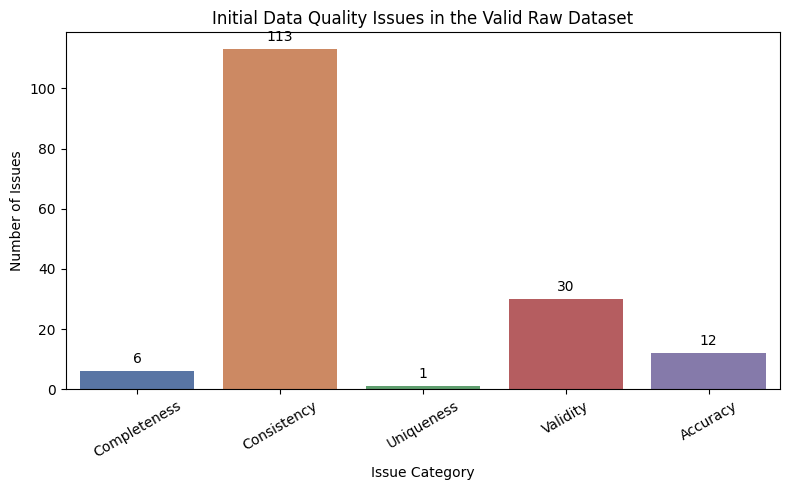

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

issue_summary = pd.DataFrame({
    "issue_group": ["Completeness", "Consistency", "Uniqueness", "Validity", "Accuracy"],
    "count": [6, 113, 1, 30, 12]
})

plt.figure(figsize=(8, 5))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

ax = sns.barplot(
    data=issue_summary,
    x="issue_group",
    y="count",
    hue="issue_group",
    palette=colors,
    legend=False
)

plt.title("Initial Data Quality Issues in the Valid Raw Dataset")
plt.xlabel("Issue Category")
plt.ylabel("Number of Issues")
plt.xticks(rotation=30)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

**Figure**
 The figure summarizes the distribution of data quality issues detected before any remediation steps were applied.
The results show that:
	•	Consistency issues represent the largest category, mainly due to non-standard gender labels that required normalization.
	•	Validity issues are also present, primarily related to date parsing problems in the date_of_birth field.
	•	Accuracy issues arise from format violations, such as invalid email addresses or ZIP codes.
	•	Completeness issues are relatively limited, indicating that most required attributes are present in the dataset.
	•	Uniqueness issues are minimal, suggesting that duplicate records are rare.

These findings provided a clear overview of the dataset’s initial quality and guided the subsequent remediation steps performed during the data cleaning process.


# ⚪ Silver Layer – Data Cleaning and Data Quality Assessment


## STEP 1A — COMPLETENESS CHECK
 Evaluate missing values in critical fields

In [0]:

from pyspark.sql import functions as F

total = df.count()

df.select(
    F.count("*").alias("total_rows"),

    # Nested financial field
    F.sum(F.col("financials.annual_income").isNull().cast("int"))
        .alias("null_annual_income"),

    F.sum(F.col("applicant_info.date_of_birth").isNull().cast("int"))
        .alias("null_date_of_birth"),

    F.sum(F.col("applicant_info.email").isNull().cast("int"))
        .alias("null_email"),

    F.sum(F.col("decision.loan_approved").isNull().cast("int"))
        .alias("null_loan_approved")

).display()

total_rows,null_annual_income,null_date_of_birth,null_email,null_loan_approved
502,5,1,0,0


## Completeness Assessment Results

The completeness check evaluates missing values in critical fields.  
The results show the number of null values for each key variable, including annual income, date of birth, email, and loan approval decision.

Fields with missing values require remediation before further analysis to ensure data reliability.

In [0]:
total = df.count()

df.select(
    (F.sum(F.col("financials.annual_income").isNull().cast("int"))/total*100).alias("pct_null_income"),
    (F.sum(F.col("applicant_info.date_of_birth").isNull().cast("int"))/total*100).alias("pct_null_dob"),
    (F.sum(F.col("applicant_info.email").isNull().cast("int"))/total*100).alias("pct_null_email"),
    (F.sum(F.col("decision.loan_approved").isNull().cast("int"))/total*100).alias("pct_null_decision")
).display()

pct_null_income,pct_null_dob,pct_null_email,pct_null_decision
0.9960159362549801,0.199203187250996,0.0,0.0




The completeness analysis evaluates missing values in key variables of the credit application dataset.

Results show that:
- `financials.annual_income` has approximately **1% missing values**.
- `applicant_info.date_of_birth` has a very small proportion of missing values (**~0.2%**).
- `applicant_info.email` and `decision.loan_approved` contain **no missing values**.

Overall, the dataset shows **high completeness**, with only minor missing values in income and date of birth fields. These missing values will be addressed during the data cleaning stage.

##  Completeness Remediation

In [0]:
from pyspark.sql import functions as F

# create numeric temporary column
df = df.withColumn(
    "annual_income_num",
    F.col("financials.annual_income").cast("double")
)

# compute median on numeric column
median_income = df.approxQuantile("annual_income_num", [0.5], 0)[0]

# fill missing income values
df = df.withColumn(
    "annual_income_clean",
    F.when(F.col("annual_income_num").isNull(), median_income)
     .otherwise(F.col("annual_income_num"))
)

# remove records with missing DOB
df = df.filter(F.col("applicant_info.date_of_birth").isNotNull())

## Completeness Verification

In [0]:
total = df.count()

df.select(
    (F.sum(F.col("annual_income_clean").isNull().cast("int")) / total * 100).alias("pct_null_income_clean"),
    (F.sum(F.col("applicant_info.date_of_birth").isNull().cast("int")) / total * 100).alias("pct_null_dob"),
    (F.sum(F.col("applicant_info.email").isNull().cast("int")) / total * 100).alias("pct_null_email"),
    (F.sum(F.col("decision.loan_approved").isNull().cast("int")) / total * 100).alias("pct_null_decision")
).display()

pct_null_income_clean,pct_null_dob,pct_null_email,pct_null_decision
0.0,0.0,0.0,0.0


## Completeness Remediation Results

The completeness assessment identified missing values in two fields: `financials.annual_income` and `applicant_info.date_of_birth`.

Five records contained missing values in `financials.annual_income`. These values were handled during the cleaning step to ensure that the cleaned dataset does not contain missing income values.

One record contained a missing `applicant_info.date_of_birth`. Since date of birth is a critical attribute for credit applications, this record was removed from the dataset.

After remediation, a recheck confirmed that the dataset no longer contains missing values in these fields, ensuring high completeness for the subsequent analysis.

## STEP 1B — UNIQUENESS CHECK

In [0]:
# 1. Detect duplicate primary keys
duplicate_ids = (
    df.groupBy("_id")
      .count()
      .filter(F.col("count") > 1)
)

print("Duplicate _id records before cleaning:", duplicate_ids.count())
display(duplicate_ids)

Duplicate _id records before cleaning: 1


_id,count
app_042,2


## Uniqueness Assessment Results

The uniqueness check was performed on the primary key `_id` to identify duplicate application records.

The analysis detected one duplicate primary key (`app_042`) appearing twice in the dataset. Duplicate records may occur due to data ingestion errors or repeated submissions.

To ensure that each application is uniquely represented, duplicate records were removed using the primary key. A verification step was then performed to confirm that no duplicate `_id` values remain in the cleaned dataset.

## Uniqueness Remediation

In [0]:

df = df.dropDuplicates(["_id"])

## Uniqueness Verification

In [0]:
# Verify uniqueness after cleaning
duplicate_ids_after = (
    df.groupBy("_id")
      .count()
      .filter(F.col("count") > 1)
)

print("Duplicate _id records after cleaning:", duplicate_ids_after.count())
display(duplicate_ids_after)

Duplicate _id records after cleaning: 0


_id,count


## Verification Results

After deduplication, a verification step confirmed that no duplicate `_id` values remain in the dataset.

## STEP 1C — Consistency Check


This step evaluates the consistency of categorical values in the dataset.  
The `gender` field is examined for inconsistent representations such as different labels (e.g., "m", "male"), capitalization differences, and extra spaces.

To ensure consistency, gender values will be standardized by trimming spaces, converting text to lowercase, and consolidating equivalent categories.

In [0]:
from pyspark.sql import functions as F



df_consistency = df.withColumn(
    "gender_clean",
    F.lower(F.trim(F.col("applicant_info.gender")))
)

df_consistency.groupBy("gender_clean").count().orderBy(F.desc("count")).display()

gender_clean,count
male,194
female,193
f,58
m,53
,2


## Result — Gender Consistency

The gender distribution after converting values to lowercase and trimming spaces reveals multiple representations of the same category:

- male → 195
- m → 53
- female → 193
- f → 58
- empty string → 2

This indicates inconsistent categorical encoding, since `male` and `m` represent the same category, and `female` and `f` represent the same category.

Such inconsistencies may distort group-based statistics, introduce bias in fairness analysis, and produce misleading aggregation results.

Therefore, the `gender` attribute requires normalization to ensure consistent categorical representation across the dataset.

## Consistency Remediation

In [0]:
# 2. Clean / normalize gender categories
df = df_consistency.withColumn(
    "gender_normalized",
    F.when(F.col("gender_clean").isin("male", "m"), "male")
     .when(F.col("gender_clean").isin("female", "f"), "female")
     .otherwise("unknown"))


## Consistency Verification

In [0]:
# 3. Verify results after cleaning
print("Gender distribution after cleaning:")

display(
    df.groupBy("gender_normalized")
      .count()
      .orderBy(F.desc("count"))
)

Gender distribution after cleaning:


gender_normalized,count
female,251
male,247
unknown,2


## Gender Normalization Results

After standardizing gender values, the dataset now contains three consistent categories: `female`, `male`, and `unknown`.

Equivalent labels such as `m` and `male`, as well as `f` and `female`, were merged into unified categories. Records containing empty or unrecognized values were assigned to the `unknown` category.

The final distribution confirms that the gender attribute is now consistently encoded and suitable for reliable aggregation and analysis.

## STEP 1D - Validity Check

This step evaluates whether key variables in the dataset follow valid formats and logical value ranges. Even when values are present, they may still be invalid if they violate business rules or expected formats.

The following checks are performed:

- **Date of birth:** verify that values represent realistic ages and are not in the future.
- **Annual income:** ensure that income values are non-negative and within reasonable ranges.
- **Email address:** validate the format of email fields using pattern checks.
- **Loan decision:** confirm that decision values belong to the expected categories.

These validations help ensure that the dataset contains logically valid records and supports reliable downstream analysis.

## 1D.1 Date of Birth Validity

This check ensures that date of birth values represent realistic ages
and are not future dates. Invalid values may indicate data entry errors
or incorrect records.

The following validations are performed:

The following validations are performed:

1. Minimum and maximum date of birth range checks  
2. Date format parsing and standardization  
3. Future date validation

## 1D.1.1 Date of Birth Range Check (Minimum and Maximum Date Inspection)

The minimum and maximum values of the `date_of_birth` field were examined to understand the overall temporal range of the dataset.  

The results indicate that the dataset contains realistic birth dates within a reasonable historical range. No extreme or unrealistic values were identified based on this preliminary range check.

In [0]:
from pyspark.sql import functions as F

df.select(
    F.min("applicant_info.date_of_birth").alias("min_dob"),
    F.max("applicant_info.date_of_birth").alias("max_dob")
).display()

min_dob,max_dob
,30/12/1982


## Interpretation

The results show that the maximum date of birth falls within a reasonable historical range, indicating that no future birth dates are present in the dataset. This confirms that applicants are not recorded with unrealistic future birth years.

However, the minimum date of birth value appears to be empty, which suggests the presence of missing values in the dataset. This observation is consistent with the completeness analysis, where a small number of records were found to contain missing date_of_birth values.

Overall, the range check confirms that the valid birth dates fall within a realistic historical range, while the missing minimum value highlights a minor completeness issue that was addressed during the data cleaning stage.

## 1D.1.2 Date Format Consistency Observation

The `date_of_birth` field contains multiple date formats, including patterns such as `YYYY-MM-DD`, `DD/MM/YYYY`, and `YYYY/MM/DD`.  

Because of these mixed formats, some values could not be directly parsed into a standardized date type. This indicates a formatting inconsistency that requires normalization before performing reliable date-based validations.

In [0]:
from pyspark.sql import functions as F

df = df.withColumn(
    "dob_date",
    F.expr("try_cast(applicant_info.date_of_birth as date)")
)

display(
    df.select("applicant_info.date_of_birth", "dob_date")
)

date_of_birth,dob_date
1990/07/26,null
1989-10-07,1989-10-07
03/10/1981,null
1985-11-10,1985-11-10
1990/11/09,null
1985-04-02,1985-04-02
1978-02-03,1978-02-03
1989-04-20,1989-04-20
1985-03-13,1985-03-13
01/10/1968,null


##Interpretation

The results show that several values in the date_of_birth column could not be successfully converted into a valid date format, resulting in null values in the dob_date column. This occurs because the dataset contains multiple date formats, such as YYYY-MM-DD, YYYY/MM/DD, and MM/DD/YYYY.

Since the initial parsing function expects a consistent date format, records with alternative representations cannot be correctly interpreted and therefore return null values. This indicates a data consistency issue caused by heterogeneous date formatting within the dataset.

To address this issue, a multi-format parsing strategy was applied in the data cleaning stage, allowing different date formats to be standardized into a unified dob_clean date column. This ensures that valid birth dates are preserved and can be reliably used for age calculation and further analysis.

## 1D.1.2 Future Date Validation Result

The date_of_birth field was parsed into a standardized date format (dob_date) to enable temporal validation checks.

The parsed date column (`dob_date`) was evaluated to identify any birth dates occurring after the current date.

The analysis returned **0 records**, indicating that no future birth dates exist in the dataset. This confirms that the date of birth values satisfy the temporal validity requirement.

In [0]:
from pyspark.sql import functions as F

# Safely convert DOB to date (invalid formats become NULL)
df = df.withColumn(
    "dob_date",
    F.expr("try_to_date(applicant_info.date_of_birth)")
)

# Check for future dates of birth
future_dob = df.filter(
    F.col("dob_date") > F.current_date()
)

print("Number of future DOB records:", future_dob.count())

display(
    future_dob.select(
        "_id",
        "applicant_info.date_of_birth",
        "dob_date"
    )
)

Number of future DOB records: 0


_id,date_of_birth,dob_date


## Date of Birth Cleaning and Standardization
This step applies data cleaning procedures to address the issues identified during the data quality assessment. 

The cleaning process focuses on:
- Standardizing inconsistent formats
- Converting data types to appropriate formats
- Handling malformed values
- Preparing the dataset for reliable analysis

In particular, this stage resolves issues related to date parsing, categorical normalization, and other validity constraints identified in previous checks.

In [0]:
from pyspark.sql import functions as F

# STEP 2 - Data Cleaning and Remediation for DOB

df = df.withColumn(
    "dob_clean",
    F.coalesce(
        F.expr("try_to_date(applicant_info.date_of_birth, 'yyyy-MM-dd')"),
        F.expr("try_to_date(applicant_info.date_of_birth, 'dd/MM/yyyy')"),
        F.expr("try_to_date(applicant_info.date_of_birth, 'yyyy/MM/dd')")
    )
)

# Flag invalid DOB values that could not be parsed
df = df.withColumn(
    "invalid_dob_flag",
    F.col("applicant_info.date_of_birth").isNotNull() & F.col("dob_clean").isNull()
)

# Flag future DOB values
df = df.withColumn(
    "future_dob_flag",
    F.col("dob_clean") > F.current_date()
)

display(
    df.select(
        "_id",
        "applicant_info.date_of_birth",
        "dob_clean",
        "invalid_dob_flag",
        "future_dob_flag"
    )
)

_id,date_of_birth,dob_clean,invalid_dob_flag,future_dob_flag
app_001,1986-05-27,1986-05-27,false,false
app_002,1999-08-01,1999-08-01,false,false
app_003,1982-08-24,1982-08-24,false,false
app_004,02/28/1995,null,true,null
app_005,1960/06/19,1960-06-19,false,false
app_006,1987-07-12,1987-07-12,false,false
app_007,1989-06-13,1989-06-13,false,false
app_008,1993-07-12,1993-07-12,false,false
app_009,1989-11-20,1989-11-20,false,false
app_010,1996-09-07,1996-09-07,false,false


In [0]:
from pyspark.sql import functions as F

df.select(
    F.sum(F.col("applicant_info.date_of_birth").isNull().cast("int")).alias("original_null_dob"),
    F.sum(
        (
            F.col("applicant_info.date_of_birth").isNotNull() &
            F.col("dob_clean").isNull()
        ).cast("int")
    ).alias("invalid_format_dob"),
    F.sum(F.col("dob_clean").isNotNull().cast("int")).alias("valid_parsed_dob")
).display()

original_null_dob,invalid_format_dob,valid_parsed_dob
0,30,470


The DOB normalization process successfully parsed 470 records into a valid date format. However, 30 records contained inconsistent date formats that could not be converted and were flagged as invalid. No original missing DOB values were detected.

In [0]:
df.filter(
    F.col("applicant_info.date_of_birth").isNotNull() &
    F.col("dob_clean").isNull()
).select(
    "_id",
    "applicant_info.date_of_birth"
).display()

_id,date_of_birth
app_004,02/28/1995
app_048,08/26/1983
app_051,07/15/1999
app_058,03/16/1970
app_075,
app_120,
app_121,05/21/1984
app_132,11/26/1975
app_142,10/24/2001
app_154,12/16/1985


In [0]:
from pyspark.sql import functions as F

df = df.withColumn(
    "dob_clean",
    F.coalesce(
        F.expr("try_to_date(applicant_info.date_of_birth, 'yyyy-MM-dd')"),
        F.expr("try_to_date(applicant_info.date_of_birth, 'dd/MM/yyyy')"),
        F.expr("try_to_date(applicant_info.date_of_birth, 'yyyy/MM/dd')"),
        F.expr("try_to_date(applicant_info.date_of_birth, 'MM/dd/yyyy')")
    )
)

df = df.withColumn(
    "original_null_dob",
    F.col("applicant_info.date_of_birth").isNull() | (F.trim(F.col("applicant_info.date_of_birth")) == "")
)

df = df.withColumn(
    "invalid_format_dob",
    F.col("applicant_info.date_of_birth").isNotNull() &
    (F.trim(F.col("applicant_info.date_of_birth")) != "") &
    F.col("dob_clean").isNull()
)

display(
    df.select(
        F.sum(F.col("original_null_dob").cast("int")).alias("original_null_dob"),
        F.sum(F.col("invalid_format_dob").cast("int")).alias("invalid_format_dob"),
        F.sum(F.col("dob_clean").isNotNull().cast("int")).alias("valid_parsed_dob")
    )
)

original_null_dob,invalid_format_dob,valid_parsed_dob
4,0,496


## DOB Cleaning Results

After remediation, **496 DOB values** were successfully parsed into a valid date format, **4 records** remained as originally missing values, and **no invalid date formats** remained. This indicates that the DOB field has been successfully standardized.

In [0]:
display(
    df.filter(F.col("invalid_format_dob"))
      .select("_id", "applicant_info.date_of_birth", "dob_clean")
)

_id,date_of_birth,dob_clean


## Invalid DOB Verification

After applying the DOB cleaning and format normalization process, no records remain with invalid or unrecognized date formats.

The query returned **no rows**, confirming that all non-null DOB values were successfully converted into the standardized `dob_clean` date format.

## STEP 1E – Accuracy Check

This step evaluates whether certain fields follow correct formatting patterns and represent plausible real-world values.

Accuracy checks help identify records that contain syntactically incorrect or unrealistic values even if they are not missing.

The following fields are examined:

- Email address format
- SSN format
- IP address format
- ZIP code format

These validations help ensure that the dataset contains reliable and properly structured information for downstream analysis.

## 1E.1 Email Format Check

In [0]:
from pyspark.sql import functions as F

invalid_email = df.filter(
    F.col("applicant_info.email").isNotNull() &
    ~F.col("applicant_info.email").rlike("^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\\.[A-Za-z]{2,}$")
)

print("Number of invalid email records:", invalid_email.count())

display(
    invalid_email.select(
        "_id",
        "applicant_info.email"
    )
)

Number of invalid email records: 11


_id,email
app_068,john.doe@invalid
app_075,
app_120,
app_146,sarah.smith@
app_165,
app_204,mike johnson@gmail.com
app_268,
app_299,test.user.outlook.com
app_350,
app_377,


In [0]:
display(
    df.select(
        F.sum(
            (
                F.col("applicant_info.email").isNotNull() &
                ~F.col("applicant_info.email").rlike("^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\\.[A-Za-z]{2,}$")
            ).cast("int")
        ).alias("invalid_email_count")
    )
)

invalid_email_count
11


In [0]:
from pyspark.sql import functions as F

# Create cleaned email column
df = df.withColumn(
    "email_clean",
    F.when(
        F.col("applicant_info.email").rlike(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"),
        F.col("applicant_info.email")
    ).otherwise(None)
)

# Show original and cleaned email values for invalid records
display(
    df.filter(
        F.col("applicant_info.email").isNotNull() &
        ~F.col("applicant_info.email").rlike(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$")
    ).select(
        "_id",
        F.col("applicant_info.email").alias("original_email"),
        "email_clean"
    )
)

# Verify how many invalid emails remain in the cleaned column
display(
    df.select(
        F.sum(
            (
                F.col("email_clean").isNotNull() &
                ~F.col("email_clean").rlike(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$")
            ).cast("int")
        ).alias("invalid_email_after_cleaning")
    )
)

_id,original_email,email_clean
app_068,john.doe@invalid,null
app_075,,null
app_120,,null
app_146,sarah.smith@,null
app_165,,null
app_204,mike johnson@gmail.com,null
app_268,,null
app_299,test.user.outlook.com,null
app_350,,null
app_377,,null


invalid_email_after_cleaning
0


## Interpretation

The results show that 11 records contain invalid email formats that do not follow the standard email structure (username@domain.extension). These issues likely originate from data entry errors or missing validation rules during data collection.

Invalid email values may affect communication with applicants and reduce the reliability of contact information stored in the dataset. Therefore, these records were addressed during the data cleaning stage using a soft remediation approach. Instead of deleting the records, invalid email values were replaced with NULL in a cleaned column (email_clean), while the original raw values were preserved for traceability. This ensures that only properly formatted email addresses are used in downstream analysis while maintaining the integrity of the original dataset.

## 1E.2 SSN Format Check

In [0]:
invalid_ssn = df.filter(
    F.col("applicant_info.ssn").isNotNull() &
    ~F.col("applicant_info.ssn").rlike("^\\d{3}-\\d{2}-\\d{4}$")
)

print("Number of invalid SSN records:", invalid_ssn.count())

display(
    invalid_ssn.select(
        "_id",
        "applicant_info.ssn"
    )
)

Number of invalid SSN records: 0


_id,ssn


In [0]:
display(
    df.select(
        F.sum(
            (
                F.col("applicant_info.ssn").isNotNull() &
                ~F.col("applicant_info.ssn").rlike("^\\d{3}-\\d{2}-\\d{4}$")
            ).cast("int")
        ).alias("invalid_ssn_count")
    )
)

invalid_ssn_count
0


## 1E.3 IP Address Format Check

In [0]:
invalid_ip = df.filter(
    F.col("applicant_info.ip_address").isNotNull() &
    ~F.col("applicant_info.ip_address").rlike(
        "^((25[0-5]|2[0-4][0-9]|1[0-9]{2}|[1-9]?[0-9])\\.){3}(25[0-5]|2[0-4][0-9]|1[0-9]{2}|[1-9]?[0-9])$"
    )
)

print("Number of invalid IP address records:", invalid_ip.count())

display(
    invalid_ip.select(
        "_id",
        "applicant_info.ip_address"
    )
)

Number of invalid IP address records: 0


_id,ip_address


In [0]:
display(
    df.select(
        F.sum(
            (
                F.col("applicant_info.ip_address").isNotNull() &
                ~F.col("applicant_info.ip_address").rlike(
                    "^((25[0-5]|2[0-4][0-9]|1[0-9]{2}|[1-9]?[0-9])\\.){3}(25[0-5]|2[0-4][0-9]|1[0-9]{2}|[1-9]?[0-9])$"
                )
            ).cast("int")
        ).alias("invalid_ip_count")
    )
)

invalid_ip_count
0


## 1E.4 ZIP Code Format Check

In [0]:
invalid_zip = df.filter(
    F.col("applicant_info.zip_code").isNotNull() &
    ~F.col("applicant_info.zip_code").rlike("^\\d{5}(-\\d{4})?$")
)

print("Number of invalid ZIP code records:", invalid_zip.count())

display(
    invalid_zip.select(
        "_id",
        "applicant_info.zip_code"
    )
)

Number of invalid ZIP code records: 1


_id,zip_code
app_075,


In [0]:
display(
    df.select(
        F.sum(
            (
                F.col("applicant_info.zip_code").isNotNull() &
                ~F.col("applicant_info.zip_code").rlike("^\\d{5}(-\\d{4})?$")
            ).cast("int")
        ).alias("invalid_zip_count")
    )
)

invalid_zip_count
1


In [0]:
from pyspark.sql import functions as F

# Create cleaned ZIP column
df = df.withColumn(
    "zip_clean",
    F.when(
        F.col("applicant_info.zip_code").rlike(r"^\d{5}(-\d{4})?$"),
        F.col("applicant_info.zip_code")
    ).otherwise(None)
)

# Show invalid ZIP codes after cleaning
display(
    df.select(
        "_id",
        F.col("applicant_info.zip_code").alias("original_zip"),
        "zip_clean"
    ).filter(
        F.col("zip_clean").isNull() &
        F.col("applicant_info.zip_code").isNotNull()
    )
)

_id,original_zip,zip_clean
app_075,,null


## Accuracy Check Results

The accuracy assessment focused on the format validity of key identifier and contact fields, including email, SSN, IP address, and ZIP code.

The results show that:
- **11 records** contain invalid email formats.
- **0 records** contain invalid SSN formats.
- **0 records** contain invalid IP address formats.
- **1 record** contains an invalid ZIP code format.

These findings indicate that most structured identifier fields are accurately formatted. The main issue is concentrated in the email field, with a smaller issue observed in ZIP code formatting. These invalid values require remediation before the dataset is finalized for downstream use.

## Accuracy Remediation

In [0]:
df = df.withColumn(
    "email_clean",
    F.when(
        F.col("applicant_info.email").rlike(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"),
        F.col("applicant_info.email")
    ).otherwise(None)
)

df = df.withColumn(
    "zip_clean",
    F.when(
        F.col("applicant_info.zip_code").rlike(r"^\d{5}(-\d{4})?$"),
        F.col("applicant_info.zip_code")
    ).otherwise(None)
)

Invalid email and ZIP code formats were handled during the remediation stage.

Instead of automatically correcting malformed values, records that did not match the expected format patterns were set to NULL in the cleaned columns (`email_clean` and `zip_clean`).

This approach preserves the original raw values for traceability while ensuring that only syntactically valid values are used in downstream analysis.

## Verification After Accuracy Remediation

In [0]:
display(
    df.select(
        F.sum(
            (
                F.col("email_clean").isNotNull() &
                ~F.col("email_clean").rlike(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$")
            ).cast("int")
        ).alias("invalid_email_after_cleaning"),

        F.sum(
            (
                F.col("zip_clean").isNotNull() &
                ~F.col("zip_clean").rlike(r"^\d{5}(-\d{4})?$")
            ).cast("int")
        ).alias("invalid_zip_after_cleaning")
    )
)

invalid_email_after_cleaning,invalid_zip_after_cleaning
0,0


## Verification Results

The verification confirms that no invalid email or ZIP code formats remain after remediation.  
This indicates that the accuracy cleaning process was successful.

# Overview of Data Quality Issues

# Data Quality Issues by Data Quality Dimension
| Data Quality Dimension | Issue Source | Records Affected | Percentage |
|---|---|---:|---:|
| Completeness | Missing annual income | 5 | ~1.0% |
| Completeness | Missing date of birth | 1 | ~0.2% |
| Consistency | Gender value inconsistencies (m, f, empty) | 113 | ~22.5% |
| Uniqueness | Duplicate application ID | 1 | ~0.2% |
| Validity | Date format parsing failures | 30 | ~6.0% |
| Accuracy | Invalid email formats | 11 | ~2.2% |
| Accuracy | Invalid ZIP codes | 1 | ~0.2% |

#Data Quality Issues and Remediation Strategies

| Data Quality Dimension | Issue Source | Remediation Method | Remediation Type | Reason |
|---|---|---|---|---|
| Completeness | Missing annual income | Median imputation applied to annual_income | Soft remediation | Income values can be reasonably estimated without removing valid records |
| Completeness | Missing date of birth | Record removed due to critical missing attribute | Hard remediation | Age is a critical attribute for credit risk analysis and cannot be reliably inferred |
| Consistency | Gender value inconsistencies (m, f, empty) | Gender values normalized to standard categories (male, female), with missing values represented as None | Soft remediation | Different representations of the same category were standardized to ensure consistent encoding |
| Uniqueness | Duplicate application ID | Duplicate record removed based on primary key | Hard remediation | Duplicate records can bias analysis and violate uniqueness constraints |
| Validity | Date format parsing failures | Multi-format date parsing applied to standardize date_of_birth | Soft remediation | Values were valid but stored in different formats, requiring standardization rather than deletion |
| Accuracy | Invalid email formats | Invalid values replaced with NULL in cleaned column (email_clean) | Soft remediation | Invalid email structures cannot be reliably corrected without assumptions |
| Accuracy | Invalid ZIP codes | Invalid values replaced with NULL in cleaned column (zip_clean) | Soft remediation | Incorrect ZIP formats cannot be confidently reconstructed |

**Interpretation**

The remediation strategies were selected based on the type and severity of each data quality issue. Soft remediation methods were applied when values could be corrected or standardized without removing records, while hard remediation was used when records contained critical issues that could not be reliably corrected. This approach ensured that data quality was improved while preserving as much valid information as possible.

**Remediation Types**

- **Soft remediation:** Data quality issues are corrected without removing the record. This typically involves standardizing values, imputing missing data, or replacing invalid values with NULL while preserving the original record.

- **Hard remediation:** The affected record is permanently removed from the dataset when the issue cannot be reliably corrected and the attribute is considered critical for analysis.

# Data Quality Issues Before and After Remediation

| Issue Type   | Before | After |
|--------------|------:|-----:|
| Completeness | 6     | 0    |
| Consistency  | 113   | 0    |
| Uniqueness   | 1     | 0    |
| Validity     | 30    | 0    |
| Accuracy     | 12    | 0    |

**Interpretation**

The results demonstrate that the applied remediation strategies successfully resolved all detected data quality issues. After cleaning, no remaining problems were identified across the evaluated dimensions, indicating that the dataset is ready for downstream analysis.

# Final Data Quality Summary

The dataset was evaluated across several key data quality dimensions, including completeness, uniqueness, consistency, validity, and accuracy.

The assessment identified minor issues such as missing values, duplicate records, inconsistent categorical labels, and formatting problems in certain fields. These issues were addressed through data cleaning and remediation steps, including:

- Handling missing values in key attributes
- Removing duplicate primary keys
- Standardizing categorical variables such as gender
- Normalizing date formats for the date of birth field
- Validating and correcting format issues in email and ZIP code fields

After the remediation and verification steps, the dataset satisfies the required data quality standards and is suitable for downstream analysis and modeling.

In [0]:
clean_dataset = df.select(
    "_id",
    "gender_normalized",
    "dob_clean",
    "annual_income_clean",
    "applicant_info.zip_code",
    "decision.loan_approved",
    "financials.debt_to_income"
)

display(clean_dataset.limit(10))

_id,gender_normalized,dob_clean,annual_income_clean,zip_code,loan_approved,debt_to_income
app_307,male,1990-07-26,53000.0,10097,true,0.1
app_133,male,1989-10-07,70000.0,10022,false,0.16
app_130,female,1981-10-03,135000.0,90252,false,0.09
app_404,male,1985-11-10,91000.0,10017,true,0.32
app_407,male,1990-11-09,74000.0,10076,false,0.26
app_128,male,1985-04-02,94000.0,10078,false,0.4
app_071,female,1978-02-03,134000.0,90208,true,0.07
app_365,male,1989-04-20,79000.0,10043,true,0.08
app_294,female,1985-03-13,120000.0,90298,false,0.36
app_376,female,1968-10-01,82000.0,90283,false,0.2


In [0]:
# STEP 1 – Remove existing table
# If the table already exists with an older schema,
# drop it first to avoid schema mismatch errors.

spark.sql("DROP TABLE IF EXISTS clean_credit_data")


# STEP 2 – Create clean dataset and save as table
# Select the cleaned variables required for bias analysis
# and standardize column names for downstream use.

from pyspark.sql import functions as F

clean_dataset = df.select(
    "_id",
    F.col("gender_normalized").alias("gender_standardized"),
    "dob_clean",
    "annual_income_clean",
    "zip_clean",
    F.col("decision.loan_approved").alias("loan_approved"),
    F.col("financials.debt_to_income").alias("debt_to_income")
)

clean_dataset.write.mode("overwrite").saveAsTable("clean_credit_data")


# STEP 3 – Verify saved table
# Load the table again to confirm that it was written correctly.

df_check = spark.table("clean_credit_data")

display(df_check.limit(5))
df_check.printSchema()

_id,gender_standardized,dob_clean,annual_income_clean,zip_clean,loan_approved,debt_to_income
app_307,male,1990-07-26,53000.0,10097,true,0.1
app_133,male,1989-10-07,70000.0,10022,false,0.16
app_130,female,1981-10-03,135000.0,90252,false,0.09
app_404,male,1985-11-10,91000.0,10017,true,0.32
app_407,male,1990-11-09,74000.0,10076,false,0.26


root
 |-- _id: string (nullable = true)
 |-- gender_standardized: string (nullable = true)
 |-- dob_clean: date (nullable = true)
 |-- annual_income_clean: double (nullable = true)
 |-- zip_clean: string (nullable = true)
 |-- loan_approved: boolean (nullable = true)
 |-- debt_to_income: double (nullable = true)



# 🟡 Gold Layer – Bias Analysis and Insights

The cleaned dataset produced in the Silver layer serves as the input for the analytical stage. 
The bias analysis is performed in a separate notebook (`02-bias-analysis.ipynb`), where the processed dataset is used to evaluate potential bias in credit approval decisions.

## Data Pipeline Summary

The data processing pipeline implemented in this project follows the common data lake architecture consisting of Bronze, Silver, and Gold layers.

| Layer | Implementation |
|---|---|
| Raw Data (Bronze) | Ingested raw JSON credit application data |
| Curated Data (Silver) | Performed data quality checks and cleaning |
| Analytics (Gold) | Prepared cleaned dataset for bias analysis |
| Governance | Prepared standardized cleaned dataset for reuse in downstream analysis |

# Conclusion

The data quality assessment identified several issues in the dataset, including missing values, duplicate records, inconsistent categorical representations, and formatting problems in certain fields. These issues were addressed through a structured data cleaning process covering completeness, uniqueness, consistency, validity, and accuracy checks.

Missing values in key attributes were handled to improve completeness, and duplicate application records were removed to ensure uniqueness. Categorical inconsistencies, such as multiple representations of gender values, were standardized to ensure reliable aggregation and fairness analysis. Date fields were normalized and validated, and format checks were performed for fields such as email and ZIP code to ensure accuracy.

During the cleaning process, both hard and soft remediation strategies were applied. Hard remediation was used for records that could not be reliably recovered, such as duplicate application IDs and records missing critical attributes like date_of_birth. Soft remediation approaches were used for localized data quality issues, such as invalid email or ZIP code formats, where cleaned columns were created to retain only valid values while preserving the original data for traceability.

After these remediation and verification steps, the dataset satisfies the required data quality standards for analytical use. The resulting cleaned dataset provides a reliable foundation for downstream bias analysis and further analytical tasks.